# DeepMine Analytics — Week 1: Exploratory Data Analysis (EDA) 
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Author:** Kingston Arockiasamy 

---

## Objective
Before building any machine learning model, we must first *understand* the data.  
This notebook performs Exploratory Data Analysis (EDA) on a predictive maintenance dataset  
that simulates real sensor readings from industrial machines — similar to equipment used in Australian mining operations.

**Key questions we answer:**
1. How many machines failed vs didn't fail?
2. Is temperature different for machines that failed?
3. What does the torque distribution look like?
4. Which failure types are most common?

---
## 1. Setup — Import Libraries
We import the core Python libraries used in every data science project.

In [1]:
# Import libraries
import pandas as pd        # Data manipulation (tables/dataframes)
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting and visualisation

---
## 2. Load the Dataset
We load the CSV file into a pandas DataFrame — think of it as opening an Excel file in Python.

In [2]:
# Load the dataset
df= pd.read_csv("ai4i2020.csv")

---
## 3. Understand the Data Structure
Before any analysis, we always inspect the data first:
- **`df.head()`** — see the first 5 rows
- **`df.info()`** — check column names, data types, and null counts
- **`df.describe()`** — summary statistics (min, max, mean, etc.)
- **`df.isnull().sum()`** — count any missing values per column

**Mining context:** In a real mining operation, missing sensor readings could mean a faulty sensor — a problem in itself. Always check for nulls before trusting your data.

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

---
## 4. Task 1 — Failure Count Analysis
**Question:** How many machines failed vs didn't fail?

We use `value_counts()` to count occurrences of each value in the `Machine failure` column.  
- `0` = machine did NOT fail  
- `1` = machine DID fail  

**Mining context:** A very low failure rate (~3%) is called a **class imbalance**. The model can cheat by always predicting 'no failure' and be 97% accurate — but completely useless on a real mining site.

In [7]:
# 1) Count machines that failed vs didn't fail
failure_counts = df['Machine failure'].value_counts().rename(index={0: "Didn't fail", 1: 'Failed'})
print(failure_counts)
print(f'\nFailure rate: {failure_counts["Failed"] / failure_counts.sum() * 100:.2f}%')

Machine failure
Didn't fail    9661
Failed          339
Name: count, dtype: int64

Failure rate: 3.39%


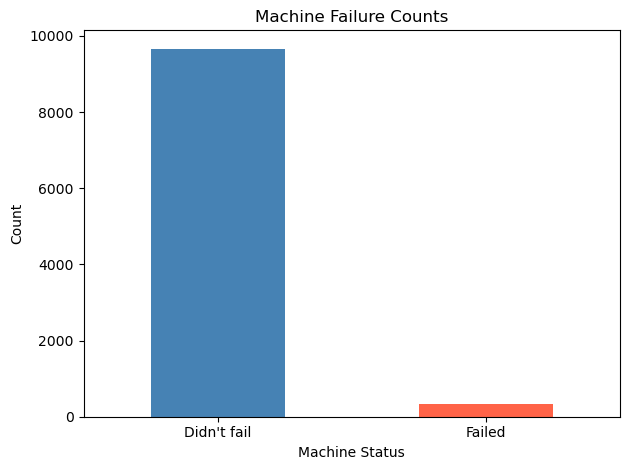

In [8]:
# Visualise failure counts
failure_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Machine Failure Counts")
plt.xlabel('Machine Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 5. Task 2 — Temperature Analysis by Failure Status
**Question:** Is the average temperature higher for machines that failed?

We check **both** temperature columns:
- `Air temperature [K]` — ambient temperature around the machine
- `Process temperature [K]` — temperature *inside* the machine during operation

**Mining context:** In mining equipment (crushers, conveyors, drill rigs), **process temperature** is far more critical than air temperature. A machine running hot internally is a strong early warning sign of failure — temperature sensors are standard on all heavy mining equipment.

In [9]:
# 2) Average temperature: failed vs didn't fail (both air and process)
avg_temps = df.groupby('Machine failure')[['Air temperature [K]', 'Process temperature [K]']].mean()
avg_temps = avg_temps.rename(index={0: "Didn't fail", 1: 'Failed'})
print(avg_temps)

                 Air temperature [K]  Process temperature [K]
Machine failure                                              
Didn't fail               299.973999               309.995570
Failed                    300.886431               310.290265


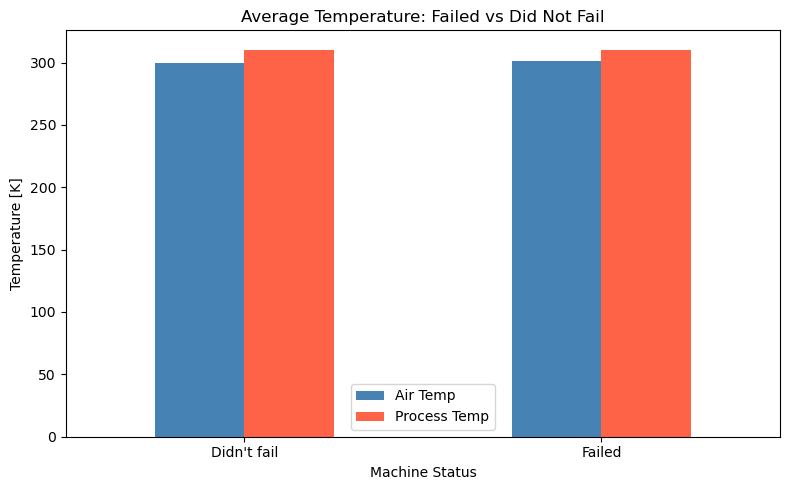

In [10]:
# Plot both temperatures side by side
avg_temps.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'tomato'])
plt.title('Average Temperature: Failed vs Did Not Fail')
plt.xlabel('Machine Status')
plt.ylabel('Temperature [K]')
plt.xticks(rotation=0)
plt.legend(['Air Temp', 'Process Temp'])
plt.tight_layout()
plt.show()

---
## 6. Task 3 — Torque Distribution
**Question:** What does the spread of torque values look like?

A **histogram** shows how frequently values fall within a range.  
Unlike a bar chart (which compares categories), a histogram shows the *shape* of a continuous variable.

**Mining context:** Torque is the rotational force applied by motors on equipment like conveyor belts and drill heads. Abnormally high torque can indicate blockages, overloading, or bearing wear — common precursors to failure in mining machinery.

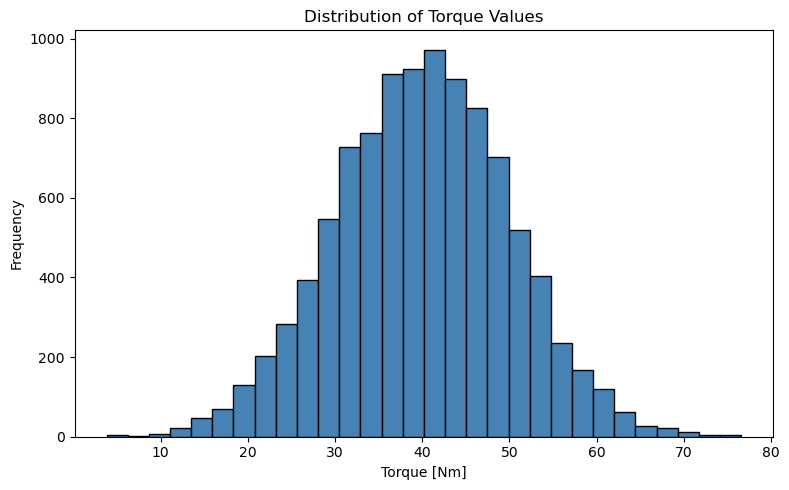

In [11]:
# 3) Histogram of torque values
plt.figure(figsize=(8, 5))
plt.hist(df['Torque [Nm]'], bins=30, edgecolor='black', color='steelblue')
plt.title('Distribution of Torque Values')
plt.xlabel('Torque [Nm]')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 7. Bonus — Failure Type Breakdown
The dataset contains 5 specific failure modes.

| Column | Failure Type | Meaning |
|--------|-------------|----------|
| TWF | Tool Wear Failure | Tool reached end of life |
| HDF | Heat Dissipation Failure | Machine overheated |
| PWF | Power Failure | Power supply issue |
| OSF | Overstrain Failure | Machine overloaded |
| RNF | Random Failure | No specific cause identified |

**Mining context:** At a BHP iron ore operation, Tool Wear and Overstrain failures are the most operationally costly — they cause unplanned downtime on critical path equipment.

In [12]:
# Count each failure type
failure_types = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum().rename({
    'TWF': 'Tool Wear',
    'HDF': 'Heat Dissipation',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain',
    'RNF': 'Random'
})
print(failure_types)

Tool Wear            46
Heat Dissipation    115
Power Failure        95
Overstrain           98
Random               19
dtype: int64


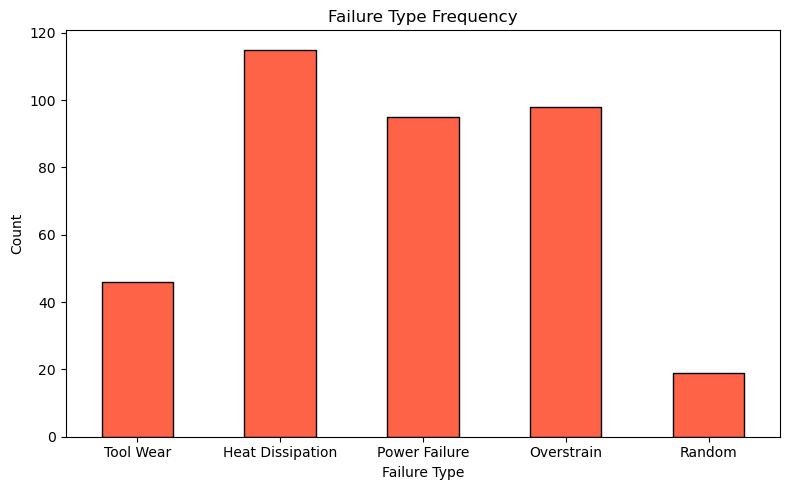

In [13]:
# Visualise failure type breakdown
failure_types.plot(kind='bar', color='tomato', edgecolor='black', figsize=(8, 5))
plt.title('Failure Type Frequency')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 8. Week 1 Summary — Key Findings

| Finding | Value |
|---------|-------|
| Total machine records | 10,000 |
| Machines that failed | 339 (3.39%) |
| Machines that did not fail | 9,661 (96.61%) |
| Avg air temp — no failure | ~299.97 K |
| Avg air temp — failed | ~300.89 K |
| Avg process temp — no failure | ~309.99 K |
| Avg process temp — failed | ~310.29 K |

### Key Takeaways
- The dataset is **heavily imbalanced** (3.39% failure rate) — this must be handled during modelling
- Failed machines run **slightly hotter** in both air and process temperature
- Temperature alone may not be enough to predict failure — need to analyse all features together
- **Next step (Week 2):** Feature correlation analysis to find the strongest predictors of failure

---
*DeepMine Analytics Virtual Internship | Week 1 Complete*